In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [28]:
# 1. Load the Dataset (Assuming 'StudentsPerformance.csv' exists)
df = pd.read_csv("StudentsPerformance.csv")

In [29]:
df.head()

,math score,reading score,writing score,placement score,placement offer count,club join year
0,80.0,68.0,70.0,89.0,3.0,2019.0
1,71.0,61.0,85.0,NaN,3.0,2019.0
2,79.0,16.0,87.0,77.0,2.0,2018.0
3,61.0,77.0,74.0,76.0,2.0,2020.0
4,78.0,71.0,67.0,90.0,3.0,2019.0


In [30]:
# --- PART 1: HANDLING MISSING VALUES ---

# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Technique: Replace missing numeric values with Mean
df['math score'] = df['math score'].fillna(df['math score'].mean())
df['reading score'] = df['reading score'].fillna(df['reading score'].median())

# Technique: Drop rows where critical data is missing
df.dropna(subset=['placement score'], inplace=True)

Missing values per column:
 math score               2
reading score            1
writing score            3
placement score          2
placement offer count    2
club join year           2
dtype: int64


In [31]:
# Detecting outliers using IQR (Interquartile Range) for Math_Score
'''Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR'''

print(f"Limits for outliers: {lower_bound} to {upper_bound}")

for col in ["math score",	"reading score"	, "writing score"	]:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    
    IQR= Q3-Q1
    
    lower_bound=Q1 - 1.5*IQR
    upper_bound=Q3+1.5*IQR
    #print(df[col])
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(f"\nFeature: {col}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")

# Technique: Outlier Treatment (Trimming/Removing)
# Keeping only data within the bounds
df = df[(df['math score'] >= lower_bound) & (df['math score'] <= upper_bound)]

# Alternative: Detecting using Z-Score
#z_scores = np.abs(stats.zscore(df['reading score']))
#df = df[z_scores < 3] # Keep data within 3 standard deviations

Limits for outliers: 49.625 to 106.625

Feature: math score
Lower Bound: 65.00
Upper Bound: 89.00
Number of Outliers: 4

Feature: reading score
Lower Bound: 46.25
Upper Bound: 88.25
Number of Outliers: 4

Feature: writing score
Lower Bound: 49.62
Upper Bound: 106.62
Number of Outliers: 1


In [32]:
for col in ["math score",	"reading score"	, "writing score"	]:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    
    IQR= Q3-Q1
    
    lower_bound=Q1 - 1.5*IQR
    upper_bound=Q3+1.5*IQR
    #print(df[col])
    outliers=df[(df[col]<lower_bound) | (df[col]>upper_bound)]
    print(f"\nFeature: {col}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")


Feature: math score
Lower Bound: 65.50
Upper Bound: 87.50
Number of Outliers: 1

Feature: reading score
Lower Bound: 46.25
Upper Bound: 88.25
Number of Outliers: 4

Feature: writing score
Lower Bound: 50.75
Upper Bound: 106.75
Number of Outliers: 1


<Axes: >

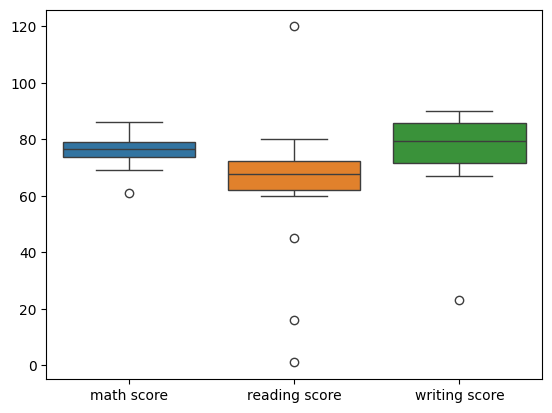

In [33]:
sns.boxplot(data=df[["math score","reading score","writing score"]])

In [21]:
# --- 3. DATA TRANSFORMATION ---
# Reason A: Change scale for better understanding (Years in Club)
# Transforming 'club join year' into 'years of membership'
df['membership_duration'] = 2024 - df['club join year']

# Reason B: Decrease skewness (Log Transformation)
# Transforming 'placement score' to normalize its distribution
df['log_placement'] = np.log10(df['placement score'])

In [22]:
df.head()

,math score,reading score,writing score,placement score,placement offer count,club join year,membership_duration,log_placement
0,80.0,68.0,70.0,89.0,3.0,2019.0,5.0,1.949390
2,79.0,16.0,87.0,77.0,2.0,2018.0,6.0,1.886491
4,78.0,71.0,67.0,90.0,3.0,2019.0,5.0,1.954243
5,73.0,68.0,90.0,80.0,2.0,NaN,NaN,1.903090
6,77.0,62.0,NaN,35.0,2.0,2020.0,4.0,1.544068



Final Statistics:
       math score  reading score  writing score  placement score  \
count   23.000000      23.000000      21.000000        23.000000   
mean    76.837359      64.282609      77.333333        82.130435   
std      4.227015      22.139448      14.234934        30.053444   
min     69.000000       1.000000      23.000000        12.000000   
25%     74.000000      62.000000      71.000000        77.000000   
50%     77.000000      67.500000      80.000000        85.000000   
75%     79.500000      71.500000      86.000000        90.000000   
max     86.000000     120.000000      90.000000       180.000000   

       placement offer count  club join year  membership_duration  \
count              21.000000       21.000000            21.000000   
mean                2.380952     2019.380952             4.619048   
std                 0.669043        0.973457             0.973457   
min                 1.000000     2018.000000             3.000000   
25%                 2.0

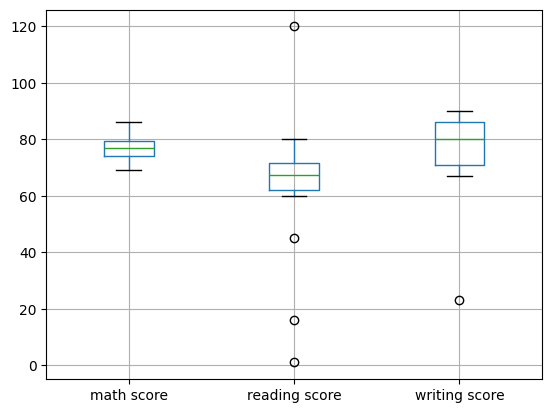

In [23]:
print("\nFinal Statistics:")
print(df.describe())

# Optional: Boxplot to verify outliers are handled
df.boxplot(column=['math score', 'reading score', 'writing score'])
plt.show()

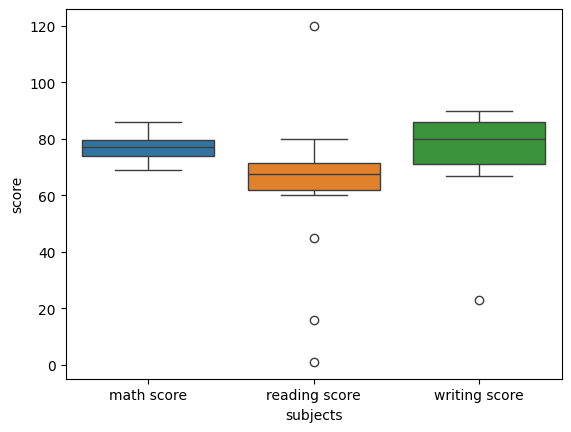

In [24]:
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.xlabel("subjects")
plt.ylabel("score")
plt.show()